# Project Part 2: Data Understanding and Preparation

- **Team number:** `#`
- **Team members:** `Cole Beach`, `Eric Lindquist`, `Tuan Lo`
- **Dataset name:** `Music Genre Classification Dataset (train.csv / test.csv)`
- **Target variable:** `Class`

## 1. Problem and Data Snapshot

- **Dataset:** We use the music classification dataset from `data/raw/train.csv` for training and `data/raw/test.csv` for prediction.
- **Machine learning problem:** This is a supervised multiclass classification problem because each song has a labeled category.
- **Target variable:** The output to predict is `Class`.
- **Main input features expected to be used:**
  - Metadata features: `Artist Name`, `Track Name`, `Popularity`
  - Audio features: `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_in min/ms`, `time_signature`

This project aims to learn patterns from track metadata and acoustic descriptors that are useful for predicting the correct music class.

## 2. Exploratory Data Analysis

This EDA uses a selective set of variables chosen for modeling relevance, distribution behavior, missingness, and relationship strength.

Dataset snapshot first: we verify overall size (`df.shape`) and schema (`df.info()` style view) so preprocessing decisions are grounded in sample size, numeric coverage, and missingness concentration. The data has enough observations for multiclass modeling, while missingness is concentrated in only a few features rather than spread uniformly.

**Focused variables:** `Popularity`, `energy`, `loudness`, `acousticness`, `instrumentalness`, `duration_in min/ms`, `speechiness`, `tempo` (target: `Class`).

This focused subset is intentional: it captures continuous audio descriptors with high modeling relevance and avoids diluting EDA with low-signal or encoding-heavy fields at this stage.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

train_path = "../data/raw/train.csv"
df = pd.read_csv(train_path)

focused_features = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "duration_in min/ms",
    "speechiness",
    "tempo",
]
target_col = "Class"

eda_df = df[focused_features + [target_col]].copy()

# Basic EDA snapshot for context before focused analysis.
print("Dataset shape (rows, cols):", df.shape)

# Audit: check availability and missingness for selected features.
schema_snapshot = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(3),
})

print("\nTop columns by missingness:")

audit = pd.DataFrame({
    "dtype": eda_df[focused_features].dtypes.astype(str),
    "missing_pct": (eda_df[focused_features].isna().mean() * 100).round(3),
    "n_unique": eda_df[focused_features].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

audit

Dataset shape (rows, cols): (17996, 17)

Top columns by missingness:


,dtype,missing_pct,n_unique
instrumentalness,float64,24.322,4253
Popularity,float64,2.378,100
loudness,float64,0.000,9002
energy,float64,0.000,1208
acousticness,float64,0.000,3930
duration_in min/ms,float64,0.000,14121
speechiness,float64,0.000,1194
tempo,float64,0.000,13562


In [2]:
summary = eda_df[focused_features].describe(percentiles=[0.25, 0.5, 0.75]).T
summary = summary.rename(columns={"50%": "median", "25%": "q1", "75%": "q3"})
summary["iqr"] = summary["q3"] - summary["q1"]
summary["missing_pct"] = eda_df[focused_features].isna().mean() * 100
summary["skew"] = eda_df[focused_features].skew(numeric_only=True)

summary_table = summary[[
    "count",
    "missing_pct",
    "mean",
    "std",
    "min",
    "median",
    "max",
    "iqr",
    "skew",
]].round(3)

summary_table

,count,missing_pct,mean,std,min,median,max,iqr,skew
Popularity,17568.0,2.378,44.512,17.427,1.000,44.000,100.000,23.000,0.076
energy,17996.0,0.000,0.663,0.235,0.000,0.700,1.000,0.351,-0.661
loudness,17996.0,0.000,-7.911,4.049,-39.952,-7.016,1.355,4.349,-1.761
acousticness,17996.0,0.000,0.247,0.311,0.000,0.081,0.996,0.430,1.105
instrumentalness,13619.0,24.322,0.178,0.304,0.000,0.004,0.996,0.200,1.531
duration_in min/ms,17996.0,0.000,200744.459,111989.127,0.502,209160.000,1477187.000,86153.000,0.847
speechiness,17996.0,0.000,0.080,0.084,0.022,0.047,0.955,0.048,3.088
tempo,17996.0,0.000,122.623,29.572,30.557,120.066,217.416,42.348,0.380


- Histogram shape confirms that `speechiness`, `acousticness`, and `duration_in min/ms` are right-skewed (positive skew means a long right tail: most tracks sit at lower values with a smaller set of extreme high values).
- This skewness matters because tails can pull linear decision boundaries and distance metrics; robust scaling is preferred over standard scaling for these features, and `log1p` is a reasonable sensitivity check for heavy-tail variables.
- `instrumentalness` has both high missingness and a mass near low values, suggesting many vocal-dominant tracks with a minority of highly instrumental songs. Keep it, impute it, and add a missing-indicator so models can capture both value signal and missingness pattern.
- `duration_in min/ms` has wide spread and clear outliers; tree ensembles usually tolerate this directly, while linear or margin-based models should use clipping/transforms to reduce instability.

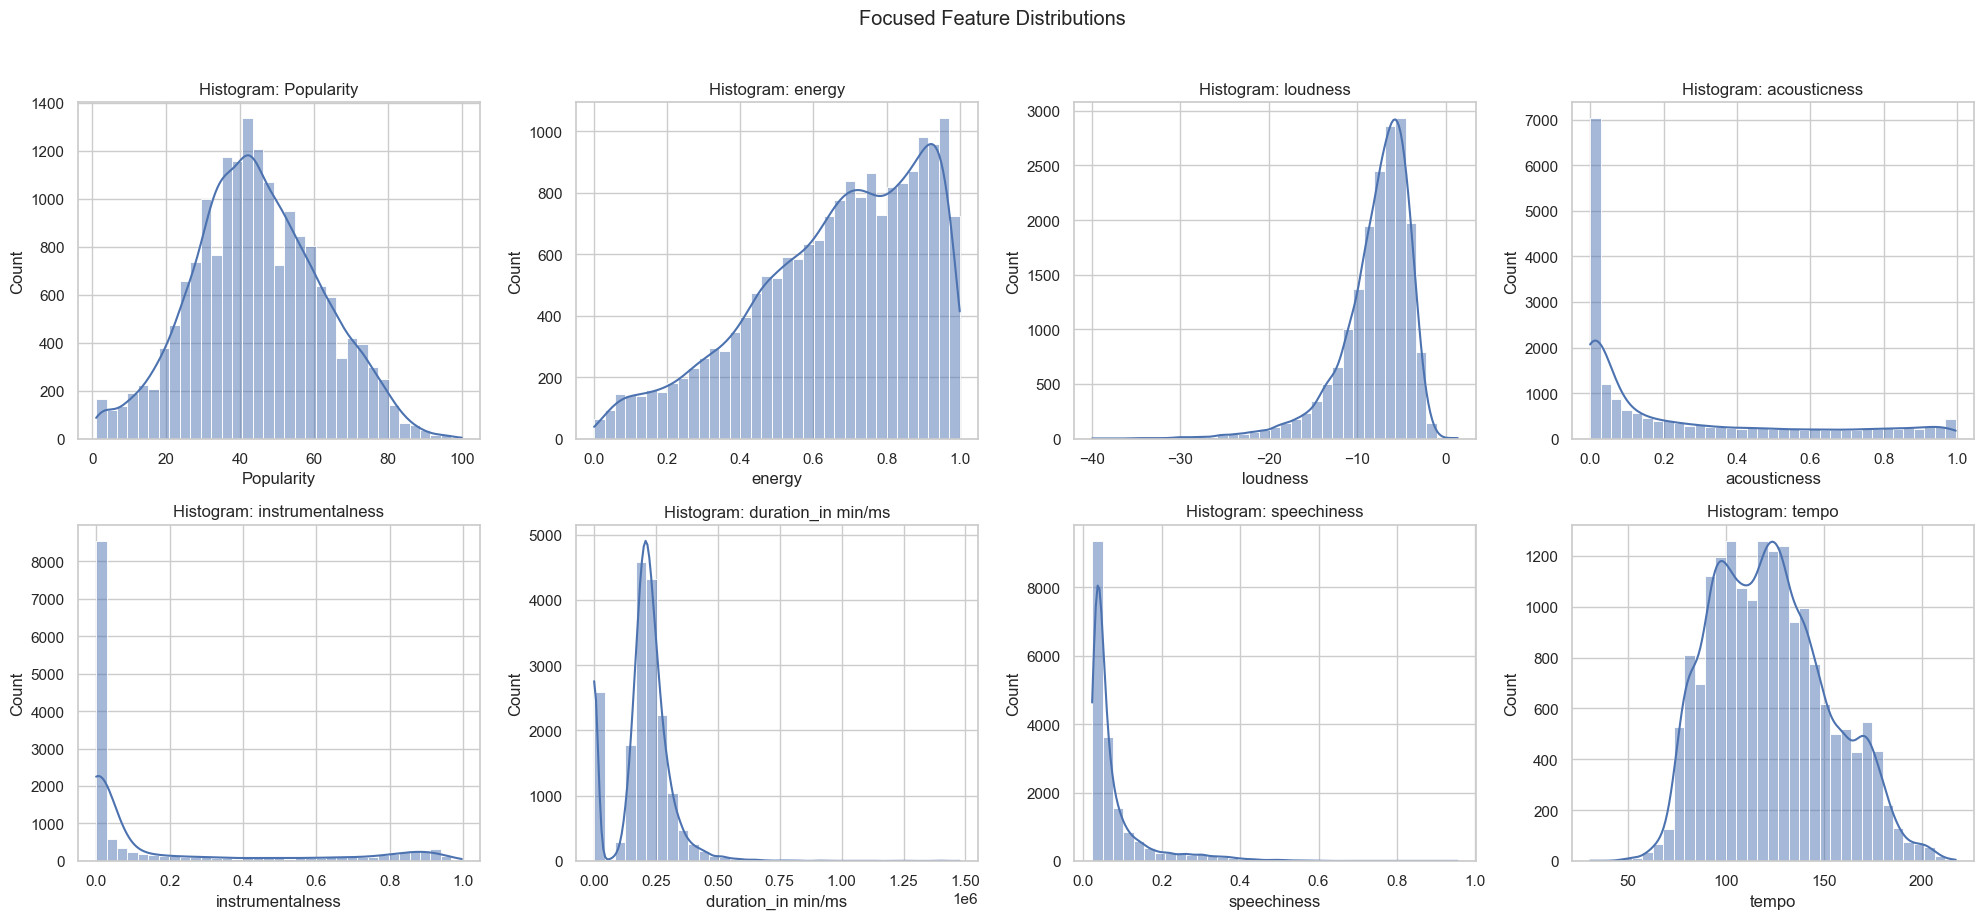

In [3]:
# Question: What are the distribution shapes and skew patterns of focused features?
plot_df = eda_df[focused_features].copy()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for i, col in enumerate(focused_features):
    ax = axes[i // 4, i % 4]
    sns.histplot(plot_df[col], bins=35, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Histogram: {col}")
    ax.set_xlabel(col)

plt.suptitle("Focused Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

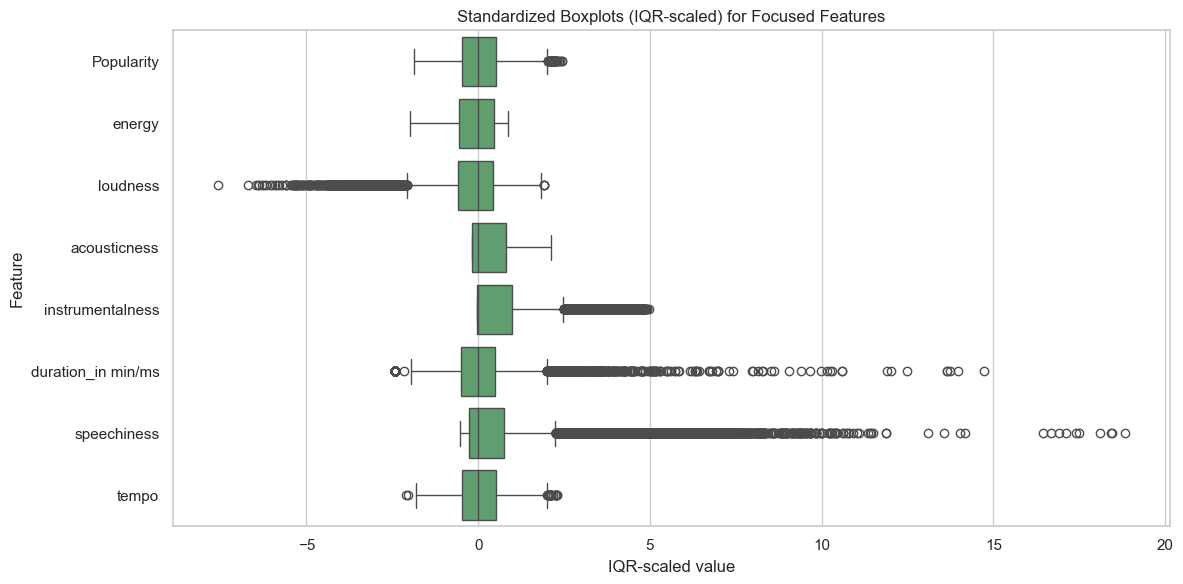

In [4]:
# Question: Which focused features have heavy tails or potential outliers?
long_df = eda_df[focused_features].melt(var_name="feature", value_name="value")

# Standardize within feature so spread is comparable in one compact chart.
long_df["z_value"] = long_df.groupby("feature")["value"].transform(
    lambda x: (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25) + 1e-9)
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=long_df, x="z_value", y="feature", orient="h", whis=1.5, color="#55A868")
plt.title("Standardized Boxplots (IQR-scaled) for Focused Features")
plt.xlabel("IQR-scaled value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

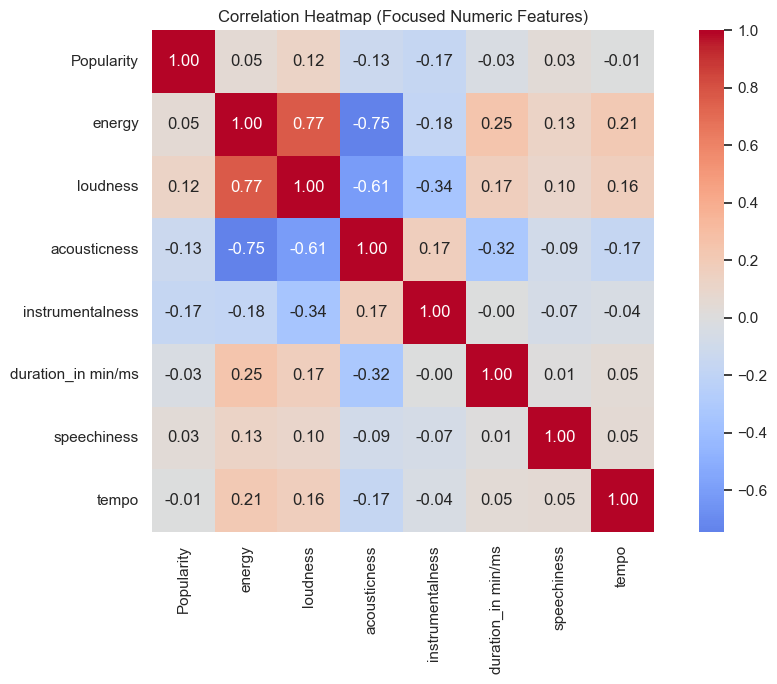

In [5]:
# Question: Which focused features move together strongly?
corr = eda_df[focused_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Focused Numeric Features)")
plt.tight_layout()
plt.show()

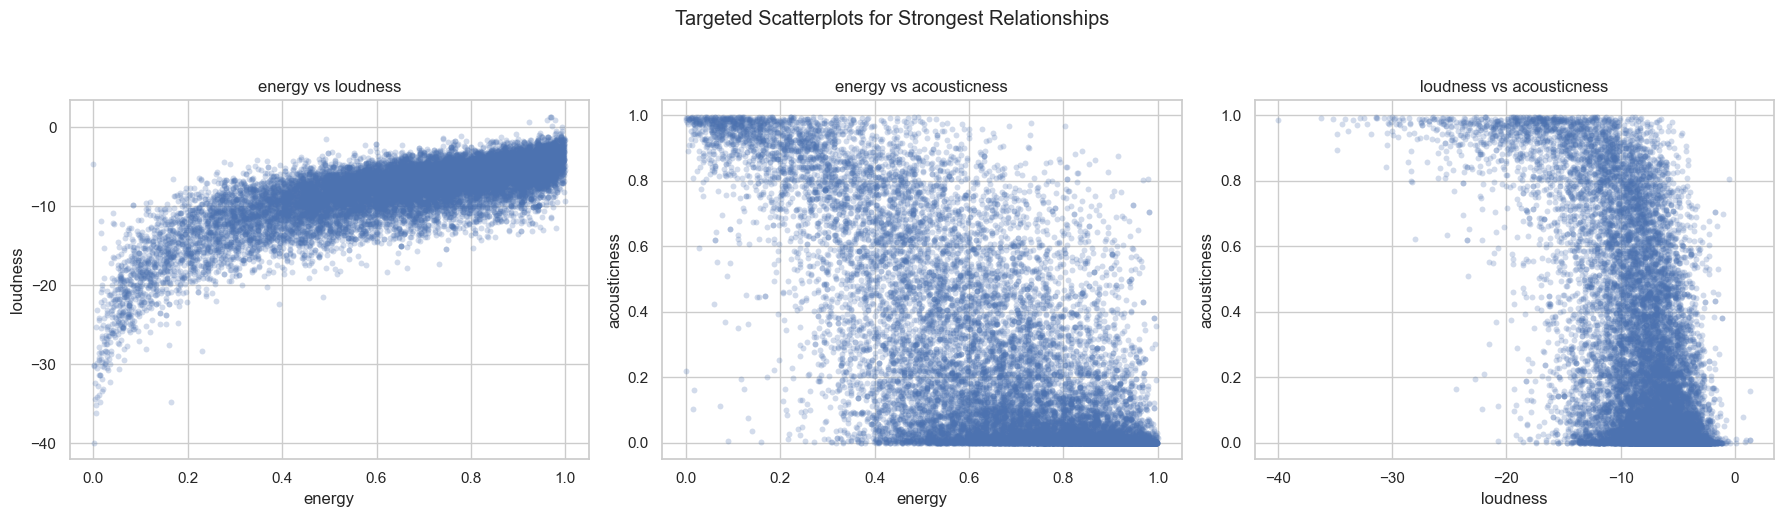

In [6]:
# Question: How do the strongest correlated feature pairs behave?
scatter_pairs = [
    ("energy", "loudness"),
    ("energy", "acousticness"),
    ("loudness", "acousticness"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=eda_df,
        x=x_col,
        y=y_col,
        alpha=0.25,
        s=18,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(f"{x_col} vs {y_col}")

plt.suptitle("Targeted Scatterplots for Strongest Relationships", y=1.03)
plt.tight_layout()
plt.show()

Correlation conclusions for modeling:

- `energy`, `loudness`, and `acousticness` form a correlated cluster (strong pairwise relationships), so they are partially redundant for linear models and can inflate coefficient variance without regularization.
- Redundancy does **not** mean immediate removal. We keep the cluster initially because each feature can still add complementary nonlinear signal, especially for tree-based models.
- Practical strategy: keep all three for baseline models, then use regularization and ablation tests to decide whether dropping one improves generalization and interpretability.

,anova_f,anova_pvalue,mutual_info
duration_in min/ms,1484.9658,0.0,0.3509
acousticness,947.4509,0.0,0.2774
energy,833.6812,0.0,0.2139
instrumentalness,551.6458,0.0,0.1718
speechiness,807.7890,0.0,0.1414
loudness,785.5009,0.0,0.1303
Popularity,203.9523,0.0,0.0978
tempo,42.5693,0.0,0.0706


Top 3 class-signal features (categorical-safe ranking): ['duration_in min/ms', 'acousticness', 'energy']


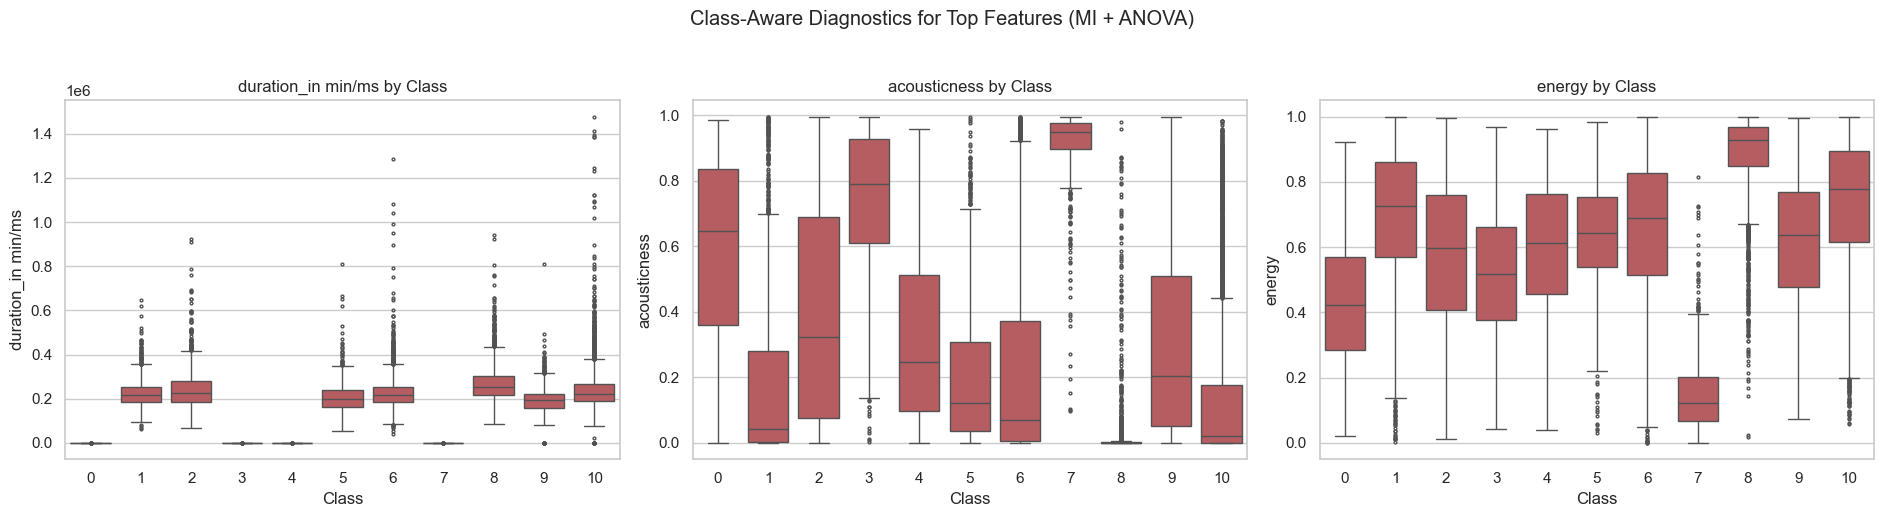

In [7]:
# Question: Which top signal features differ most across classes?
# `Class` is categorical, so Pearson correlation to class codes is not appropriate.
from sklearn.feature_selection import f_classif, mutual_info_classif

X = eda_df[focused_features].copy()
y = eda_df[target_col].copy()

# Handle missingness for score computation.
X_imputed = X.fillna(X.median(numeric_only=True))

f_vals, p_vals = f_classif(X_imputed, y)
mi_vals = mutual_info_classif(X_imputed, y, random_state=42)

signal_rank = pd.DataFrame({
    "anova_f": f_vals,
    "anova_pvalue": p_vals,
    "mutual_info": mi_vals,
}, index=focused_features).sort_values(["mutual_info", "anova_f"], ascending=False)

display(signal_rank.round(4))

top3_by_class_signal = signal_rank.head(3).index.tolist()
print("Top 3 class-signal features (categorical-safe ranking):", top3_by_class_signal)

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=False)
for ax, feature in zip(axes, top3_by_class_signal):
    sns.boxplot(data=eda_df, x=target_col, y=feature, ax=ax, color="#C44E52", fliersize=2)
    ax.set_title(f"{feature} by Class")
    ax.set_xlabel("Class")

plt.suptitle("Class-Aware Diagnostics for Top Features (MI + ANOVA)", y=1.03)
plt.tight_layout()
plt.show()

In [8]:
# Question: Is class imbalance large enough to affect model training and evaluation?
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

class_balance = pd.DataFrame({
    "count": class_counts,
    "pct": class_pct,
})

print(f"Imbalance ratio (largest/smallest class): {imbalance_ratio:.2f}x")
class_balance

Imbalance ratio (largest/smallest class): 12.79x


,count,pct
Class,,
0,625,3.47
1,1373,7.63
2,1272,7.07
3,402,2.23
4,387,2.15
5,1447,8.04
6,2587,14.38
7,576,3.20
8,1854,10.30


### Modeling implications

1. **Imputation first:** keep `instrumentalness`, apply median imputation, and add a missing-indicator so missingness can be learned as signal.
2. **Encoding choices:** treat `key` as categorical (not continuous) if included; remove it if cross-validation shows negligible gain.
3. **Scale/transform policy:** use robust scaling for skewed heavy-tail variables (`speechiness`, `acousticness`, `duration_in min/ms`), then test `log1p` as an ablation for linear-distance models.
4. **Correlation management:** keep `energy`/`loudness`/`acousticness` initially; control redundancy with regularization and feature-drop ablations, especially for linear models.
5. **Class-aware training/evaluation:** because classes are imbalanced, prioritize macro-F1 and balanced accuracy, and start with class weights before oversampling.
6. **Leakage-risk check:** compare metadata-augmented models against audio-only baselines to ensure performance is not driven by brittle dataset shortcuts.
7. **Validation discipline:** lock all preprocessing in a pipeline and confirm each EDA-motivated choice through cross-validated ablation, not EDA alone.

In [ ]:
## 1. Problem and Data Snapshot

- **Dataset:** We use the music classification dataset from `data/raw/train.csv` for training and `data/raw/test.csv` for prediction.
- **Machine learning problem:** This is a supervised multiclass classification problem because each song has a labeled category.
- **Target variable:** The output to predict is `Class`.
- **Main input features expected to be used:**
  - Metadata features: `Artist Name`, `Track Name`, `Popularity`
  - Audio features: `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_in min/ms`, `time_signature`

This project aims to learn patterns from track metadata and acoustic descriptors that are useful for predicting the correct music class.